# Exploratory Data Analysis Project

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Import necessary packages for this EDA project.**

## 1. Data Loading

In [ ]:
spotify_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv "
df = pd.read_csv(spotify_url)
df.head()

**In this section, I loaded the csv file using pandas and a variable containing the url to the csv file.**

## 2. Creating Transformed Outcome Variable

In [ ]:
df['track_popularity_shifted'] = np.where(df.track_popularity == 100, df.track_popularity - 0.1, df.track_popularity)  
df['track_popularity_shifted'] = np.where(df.track_popularity == 0, df.track_popularity + 0.1, df.track_popularity_shifted)  

df['track_popularity_fraction'] = df.track_popularity_shifted/100

df['track_popularity_transformed'] = np.log(df.track_popularity_fraction / (1 - df.track_popularity_fraction)) 
df.head()

In [ ]:
df = df.drop(columns=['track_popularity', 'track_popularity_shifted', 'track_popularity_fraction'])
df

**In this section, I implemented the code that transformed the outcome variable that makes the outcome variable more suitable for a linear regression model in the future. I then deleted the original `track_popularity` variable, `track_popularity_shifted`, and `track_popularity_fraction` variables.**

## 3. Initial Exploration

#### Number of Rows and Columns:

In [6]:
df.shape

(32833, 23)

The Spotify Songs dataset contains 32833 rows and 23 columns.

#### Column Names and Their Associated Data Types:

In [7]:
df.dtypes

track_id                         object
track_name                       object
track_artist                     object
track_album_id                   object
track_album_name                 object
track_album_release_date         object
playlist_name                    object
playlist_id                      object
playlist_genre                   object
playlist_subgenre                object
danceability                    float64
energy                          float64
key                               int64
loudness                        float64
mode                              int64
speechiness                     float64
acousticness                    float64
instrumentalness                float64
liveness                        float64
valence                         float64
tempo                           float64
duration_ms                       int64
track_popularity_transformed    float64
dtype: object

The Spotify Songs dataset contains 23 columns with a mix of object, int64, and float64 data types. 

#### Number of Missing Values for Each Column:

In [8]:
df.isna().sum()

track_id                        0
track_name                      5
track_artist                    5
track_album_id                  0
track_album_name                5
track_album_release_date        0
playlist_name                   0
playlist_id                     0
playlist_genre                  0
playlist_subgenre               0
danceability                    0
energy                          0
key                             0
loudness                        0
mode                            0
speechiness                     0
acousticness                    0
instrumentalness                0
liveness                        0
valence                         0
tempo                           0
duration_ms                     0
track_popularity_transformed    0
dtype: int64

The Spotify Songs dataset contains 5 missing values in these variables: `track_name`, `track_artist`, and `track_album_name`.

#### Number of Unique Values for Each Column:

In [9]:
df.nunique()

track_id                        28356
track_name                      23449
track_artist                    10692
track_album_id                  22545
track_album_name                19743
track_album_release_date         4530
playlist_name                     449
playlist_id                       471
playlist_genre                      6
playlist_subgenre                  24
danceability                      822
energy                            952
key                                12
loudness                        10222
mode                                2
speechiness                      1270
acousticness                     3731
instrumentalness                 4729
liveness                         1624
valence                          1362
tempo                           17684
duration_ms                     19785
track_popularity_transformed      101
dtype: int64

The Spotify Songs dataset contains a variety of unique values for all columns, most notably, there are 28,356 unique track ids with 32,833 total songs. 

**In this section, I performed the essential activities for exploring the dataset. I found that there are 5 missing values in three variables that could have possible implications in the future. I also found that there are 28,356 unique track ids with 32,833 total songs which is interesting because I would assume that those numbers would be the same.**

## 4. Treatment of Variables

#### Which variables are identifiers that are not useful variables for visualization? ####

Variables such as `track_id`, `track_album_id`, and `playlist_id` are identifiers and are not useful variables for visualization. 

#### Which variables would you like to focus on for this exploratory analysis? ####

For this exploratory analysis, I would like to focus on these 8 variables: `playlist_genre`, `playlist_subgenre`, `danceability`, `energy`, `loudness`, `instrumentalness`, `valence`, `tempo`. The categorical variables are he two playlist variables, `playlist_genre` and `playlist_subgenre`, while the other six variables are numeric variables.

#### Are there any numeric variables that you want to treat as categorical for exploration purposes? ####

No, there are no numeric variables that I want to treat as categorical. The numeric variables that I have chosen simply have too many unique values to be considered categorical. 

**In this section, I identified the identifier variables that will not be useful for visualization in this project. I also chose my 8 variables that I will be focusing on for this exploratory analysis and found that none of the numeric variables are suitable to be considered categorical because they contain too many unique values.**

## 5. Summary Statistics

#### Counts of each unique value per categorical variable: ####

In [10]:
df.playlist_genre.value_counts()

playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

Each genre contains between 4591-6043 songs.

In [11]:
df.groupby('playlist_genre')['playlist_subgenre'].value_counts()

playlist_genre  playlist_subgenre        
edm             progressive electro house    1809
                pop edm                      1517
                electro house                1511
                big room                     1206
latin           latin hip hop                1656
                tropical                     1288
                latin pop                    1262
                reggaeton                     949
pop             indie poptimism              1672
                electropop                   1408
                dance pop                    1298
                post-teen pop                1129
r&b             neo soul                     1637
                urban contemporary           1405
                hip pop                      1256
                new jack swing               1133
rap             southern hip hop             1675
                gangster rap                 1458
                hip hop                      1322
        

Each subgenre contains between 949-1809 songs.

#### Summary statistics (mean, min, max, and std) for each continuous variable: ####

In [12]:
df.danceability.describe()

count    32833.000000
mean         0.654850
std          0.145085
min          0.000000
25%          0.563000
50%          0.672000
75%          0.761000
max          0.983000
Name: danceability, dtype: float64

Based on these numbers, we can see that the majority of the songs lie above the middle 50% which means that they are more suitable than not for dancing. 

In [56]:
df.energy.describe()

count    32833.000000
mean         0.698619
std          0.180910
min          0.000175
25%          0.581000
50%          0.721000
75%          0.840000
max          1.000000
Name: energy, dtype: float64

Based on these numbers, we can see that the majority of the songs lie above the middle 50% which means that they are not low energy. They appear to mostly be between 58%-84%, so they do not seem to be close to death metal which is high energy but they are higher energy.

In [14]:
df.loudness.describe()

count    32833.000000
mean        -6.719499
std          2.988436
min        -46.448000
25%         -8.171000
50%         -6.166000
75%         -4.645000
max          1.275000
Name: loudness, dtype: float64

Based on the mean and the range, we can see that most of the songs are loud. There seems to be a max of 1.275 which may be an outlier in the dataset.

In [15]:
df.instrumentalness.describe()

count    32833.000000
mean         0.084747
std          0.224230
min          0.000000
25%          0.000000
50%          0.000016
75%          0.004830
max          0.994000
Name: instrumentalness, dtype: float64

Based on the mean, we can see that there seems to be very few songs that contain no vocal content. This means that the most of the songs have consistent vocals.

In [16]:
df.valence.describe()

count    32833.000000
mean         0.510561
std          0.233146
min          0.000000
25%          0.331000
50%          0.512000
75%          0.693000
max          0.991000
Name: valence, dtype: float64

These numbers seem to be evenly distributed, meaning that there is an even mix of positive and negative sounding songs. 

In [17]:
df.tempo.describe()

count    32833.000000
mean       120.881132
std         26.903624
min          0.000000
25%         99.960000
50%        121.984000
75%        133.918000
max        239.440000
Name: tempo, dtype: float64

With the mean sitting at around 121 BPM and the range being 0-239 BPM, we can see that the songs seem to have a moderatedly paced tempo.

In [18]:
df.track_popularity_transformed.describe()

count    32833.000000
mean        -0.827397
std          2.212342
min         -6.906755
25%         -1.152680
50%         -0.200671
75%          0.489548
max          6.906755
Name: track_popularity_transformed, dtype: float64

With the mean sitting just below the middle of the range, -6.9-6.9, we can see that most of the songs are evenly distributed in popularity.

## 6. Marginal Distributions

#### Categorical Variables: ####

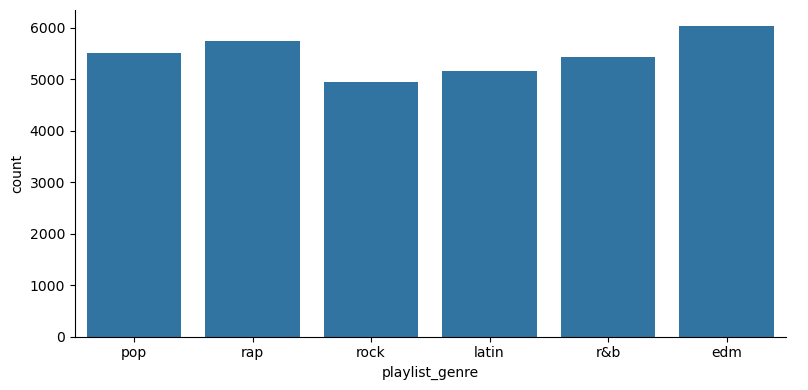

In [19]:
sns.catplot(data=df, x='playlist_genre', kind='count', aspect=2, height=4)
plt.show()

This chart shows the distribution of songs and their distributions in the dataset. It seems that EDM has the most amount of songs with Rock having the least amount of songs.

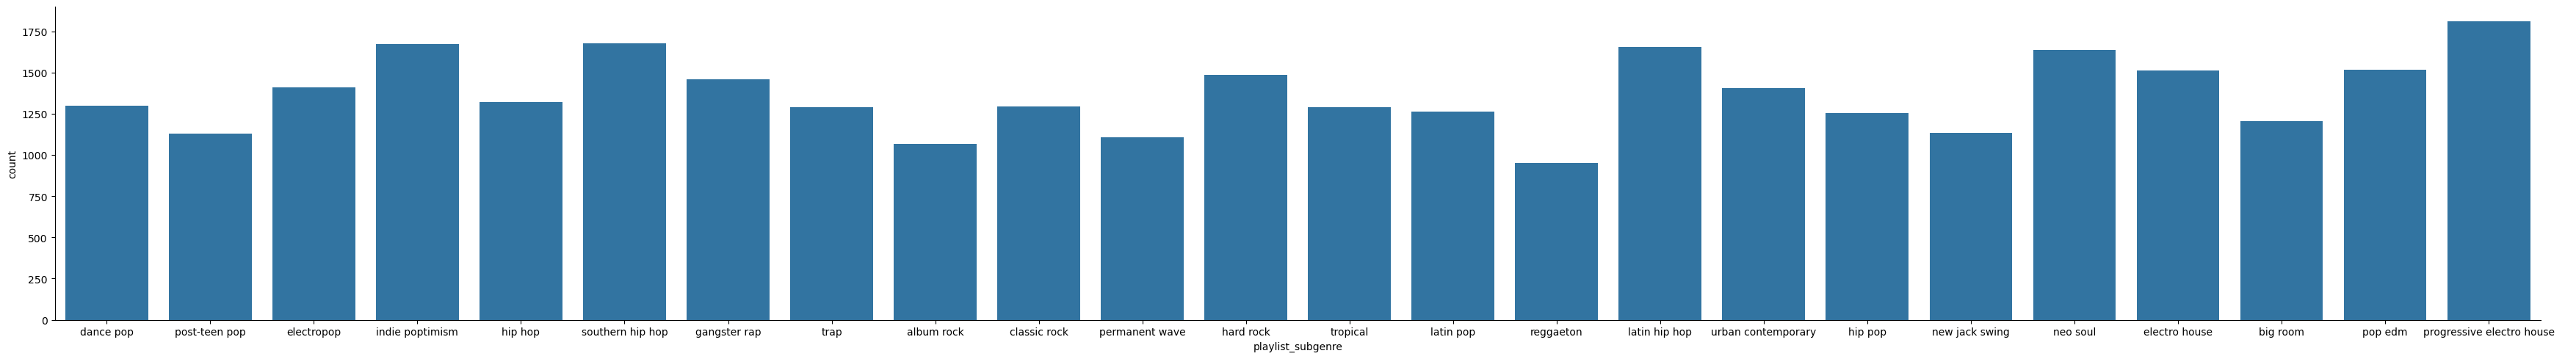

In [20]:
sns.catplot(data=df, x='playlist_subgenre', kind='count', aspect=7, height=5)
plt.show()

This chart shows the distribution of songs and their subgenre in the dataset. Although they are part of different genres, there seems to be a significant difference in count between the Reggaeton and Progressive Electro House subgenres.

#### Continuous Variables: ####

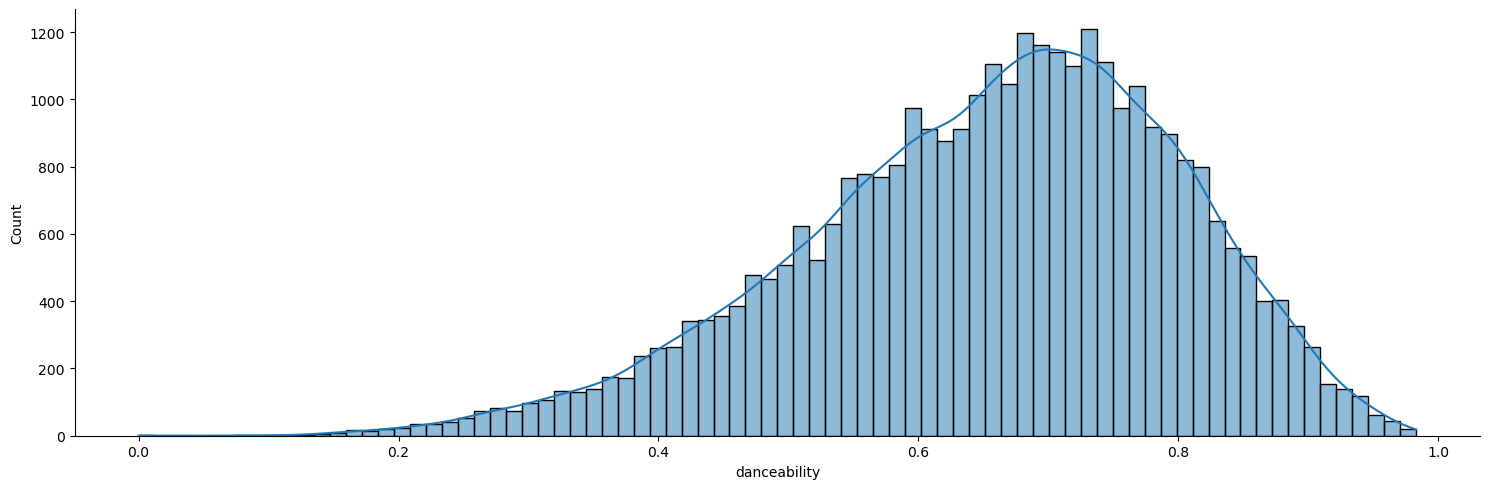

In [21]:
sns.displot(data=df, x='danceability', kind='hist', kde=True, aspect=3)
plt.show()

This histogram shows the distribution of the count of values across the `danceability` variable. I added a KDE plot to aid the histogram in showing the skewness of the distribution. It seems that most of the values lie around the 0.6-0.8 range which means that the chart aligns with the statistics calculated in the previous section. 

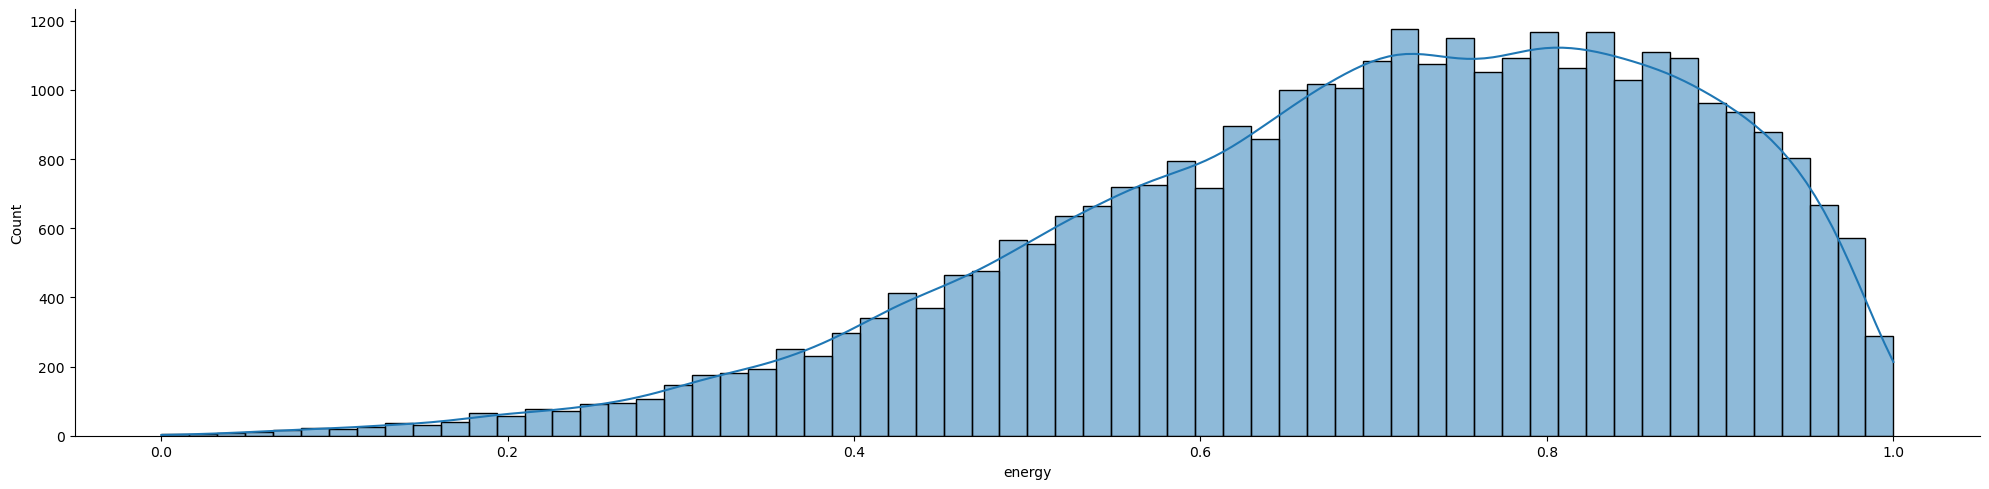

In [22]:
sns.displot(data=df, x='energy', kind='hist', kde=True, aspect=4)
plt.show()

This histogram shows the distribution of the count of values across the `energy` variable. Similar to the previous chart, I added a KDE plot to help show the skewness of the distribution. Again, like the previous chart, the chart seems to align with the statistics calculated in the previous section meaning that most of the songs are higher energy. 

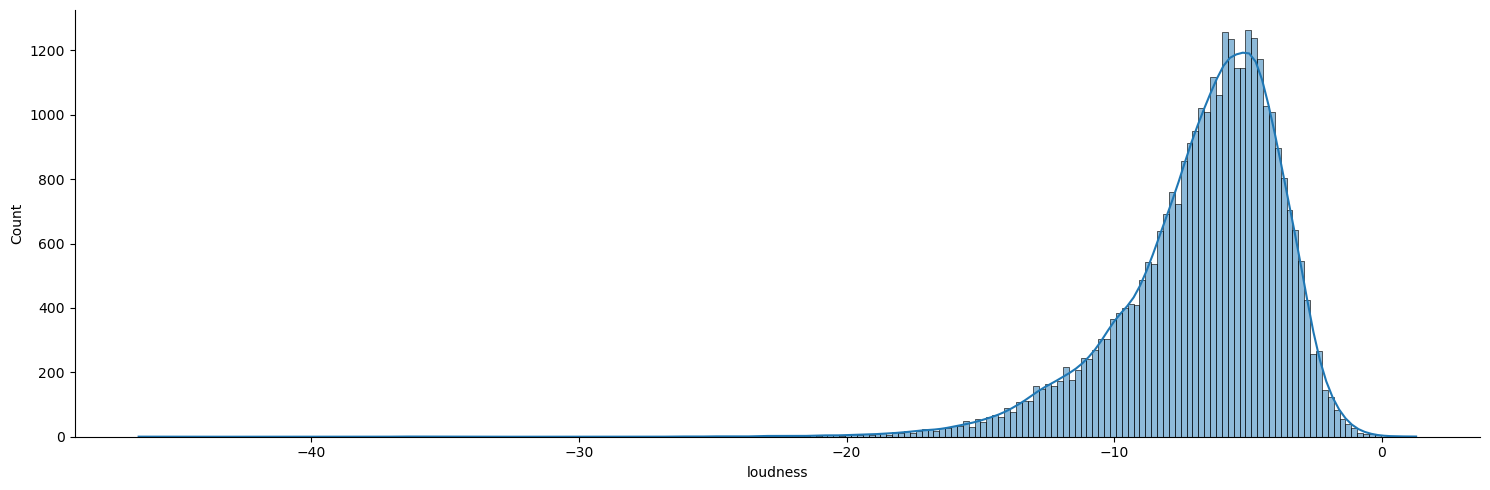

In [23]:
sns.displot(data=df, x='loudness', kind='hist', kde=True, aspect=3)
plt.show()

This histogram shows the distribution of the count of values across the `loudness` variable. Although the chart seems to be skewed, unlike the previous two charts, there seems to be a much more significant skewness of values. This means that most of the songs are significantly louder than not. Using a KDE plot helps show the sheer skewness of values. 

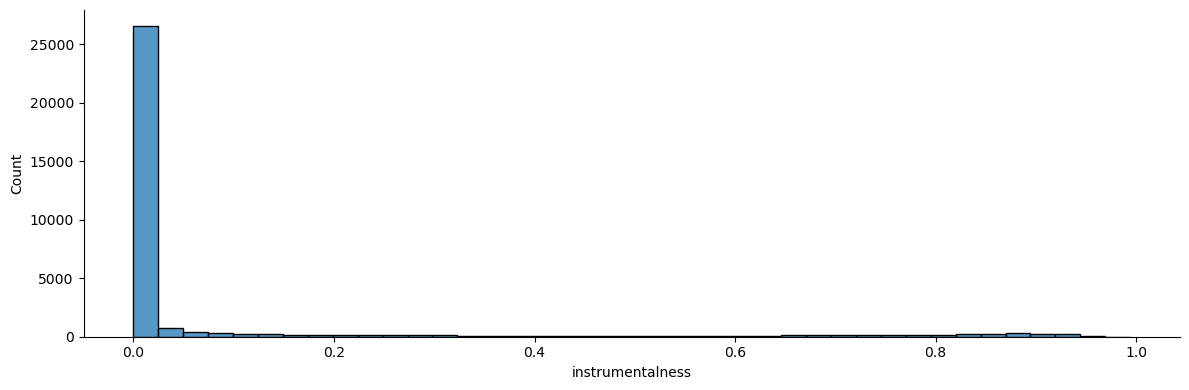

In [24]:
sns.displot(data=df, x='instrumentalness', kind='hist', aspect=3, height=4, bins=40)
plt.show()

This histogram shows the distribution of the count of values across the `instrumentalness` variable. It is apparent that there are very few songs that contain no vocals. There was no need to use a KDE plot because the histogram on its own shows the skewness of values. 

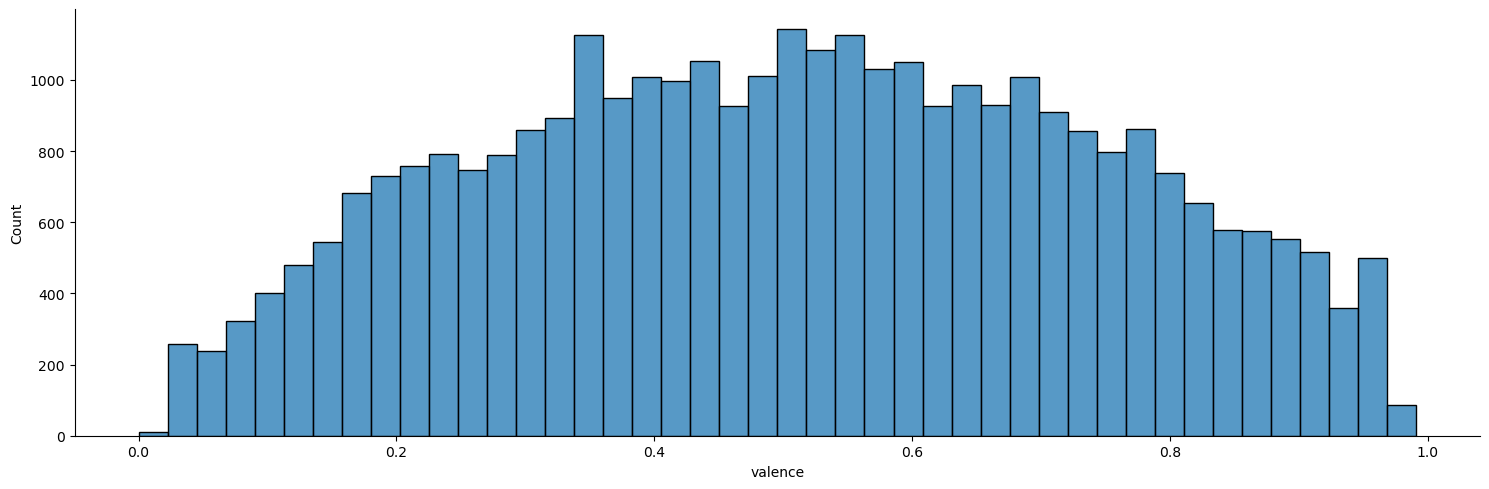

In [25]:
sns.displot(data=df, x='valence', kind='hist', aspect=3)
plt.show()

This histogram shows the distribution of the count of values across the `valence` variable. It is clear that the distribution of values is centered around the 0.3-0.6 range meaning that most of the songs are not too positive and not too negative sounding.

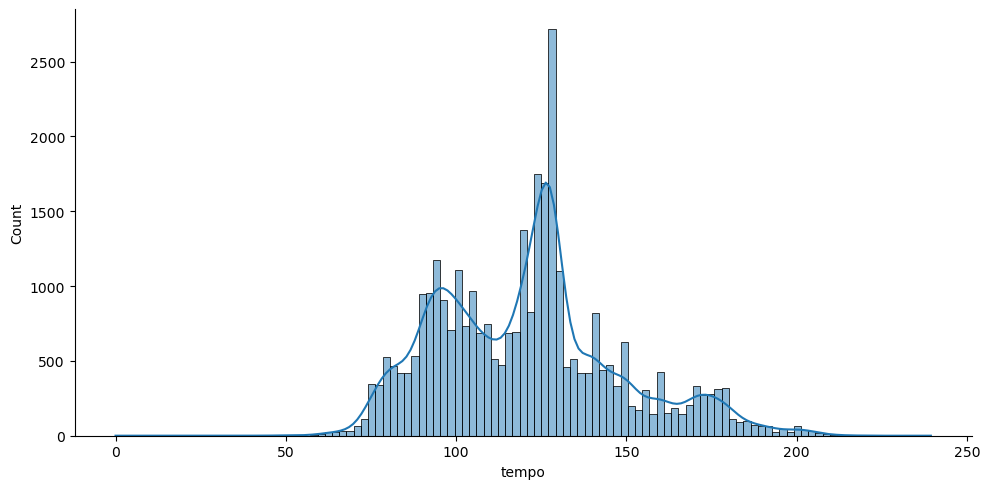

In [26]:
sns.displot(data=df, x='tempo', kind='hist', aspect=2, kde=True)
plt.show()

This histogram shows the distribution of the count of values across the `tempo` variable. It is clear that the values are heavily centered around the 100-130 range meaning that most of the songs have a moderately paced tempo.

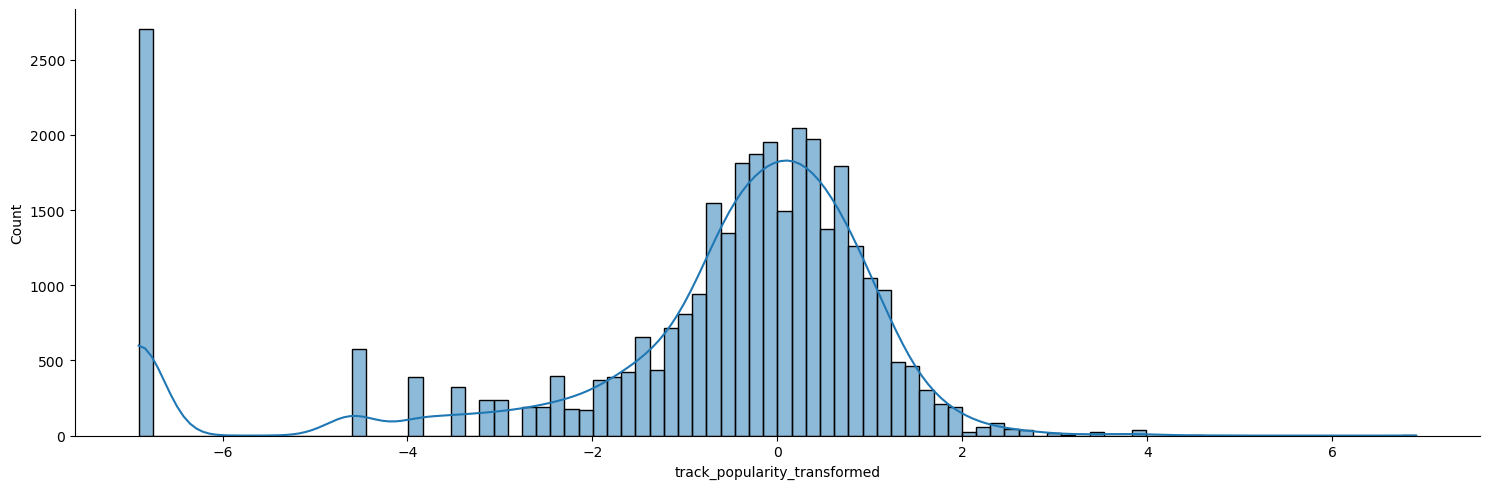

In [27]:
sns.displot(data=df, x='track_popularity_transformed', kind='hist', aspect=3, bins=90, kde=True)
plt.show()

This hisrogram shows the distribution of the count of values across the `track_popularity_transformed` variable. There seems to be a considerable amount outliers in the far negative values. Besides those outliers, the distribution seems to be otherwise a normal distribution. 

**In this section, I explored the marginal distributions of each variable I chose to focus on. All of the charts seem to align with the statistics calculated in the previous section which was expected; however, there seemed to a significant amount outliers which was not expected.**

## 7. Relationships Among Variables

#### Categorical-to-categorical: ####

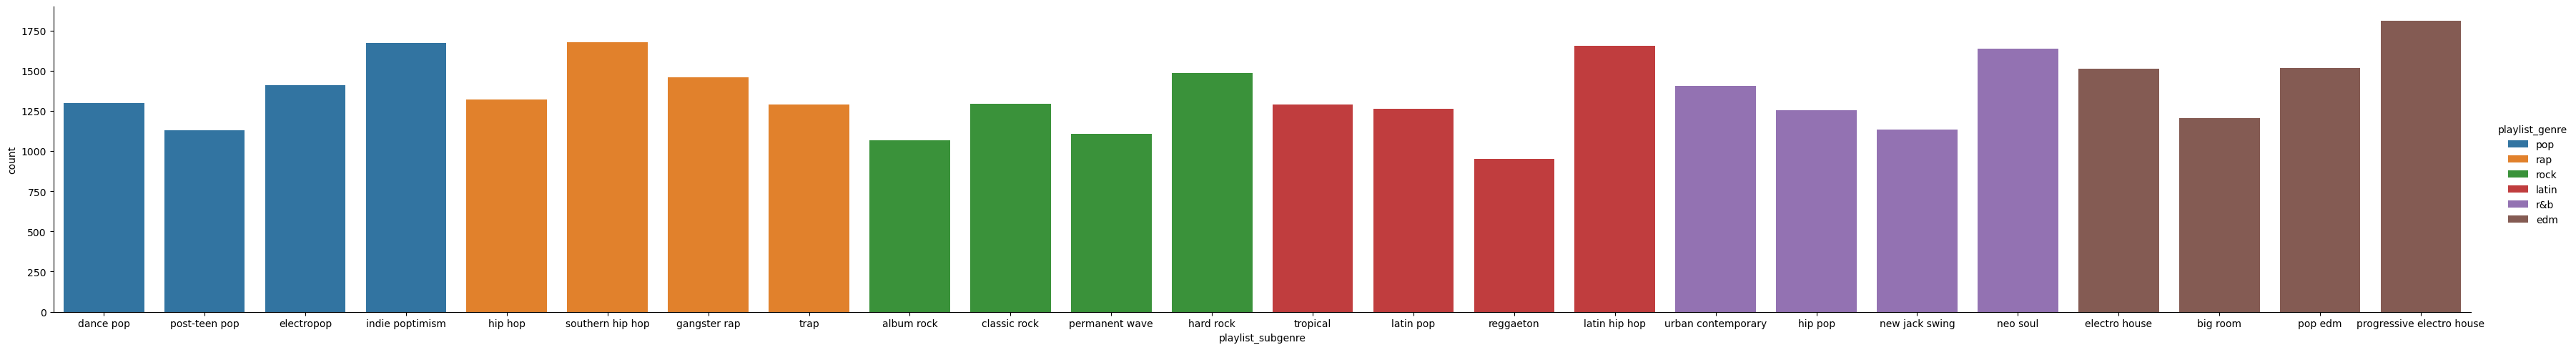

In [28]:
sns.catplot(data=df, x='playlist_subgenre', hue='playlist_genre', kind='count', aspect=7)
plt.show()

This bar chart shows the relationship between the two playlist variables: `playlist_genre`and `playlist_subgenre`. Based on the previous numbers discovered of the distribution of songs per genre, we can see that there is a somewhat even distribution. I used a bar chart to help show the distributions better.

#### Categorical-to-continuous: ####

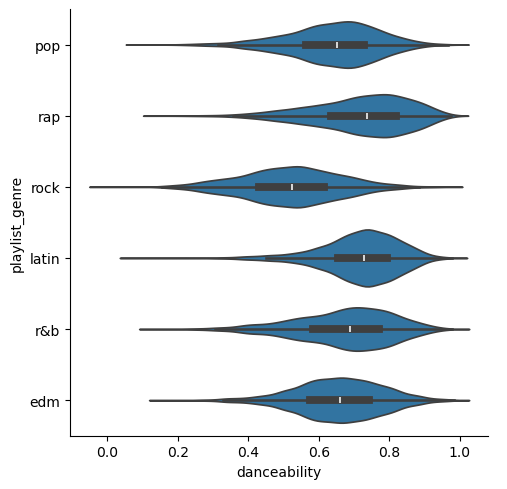

In [51]:
sns.catplot(data=df, x='danceability', y='playlist_genre', kind='violin')
plt.show()

This violin plot shows the relationship between the two variables: `playlist_genre` and `danceability`. We can see that the Rock genre has the lowest values out of the five other genres. We can also see that values for the Latin genre are heavily concentrated at the 0.7-0.8 range. Based on the plot, we can suggest that Latin and Rap are the two most danceable genres where as Rock is the least danceable genre. I decided to use a violin plot for this comparison because of its displaying capabilities including the box plot.

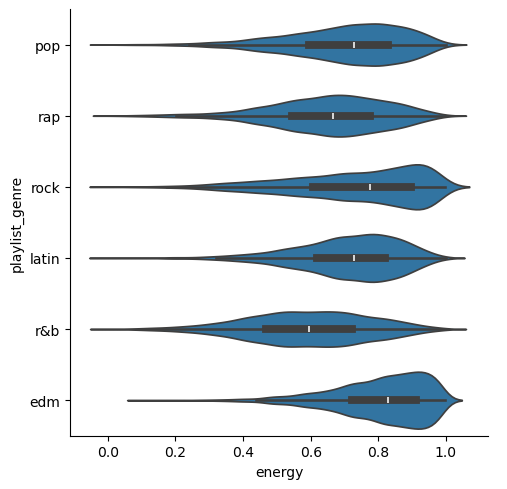

In [50]:
sns.catplot(data=df, x='energy', y='playlist_genre', kind='violin')
plt.show()

This violin plot shows the relationship between the two variables: `energy` and `playlist_genre`. We can see that EDM has the highest overall energy values than the rest of the genres because most of its values are concentrated at a higher energy value range. R&B seems to have the lowest overall energy value concentration, sitting closer to the middle of the chart. The other four genres seem to be near each other, with Rap hanging a little lower and Rock standing a bit higher in energy values. Similarly to the previous chart, I decided to use a violing plot because of its displaying capabilites.

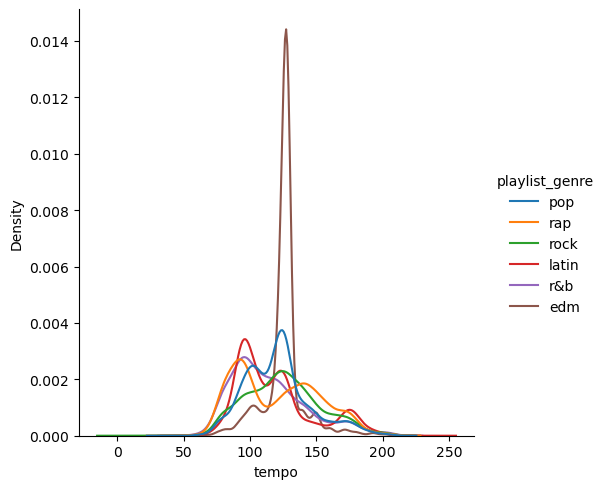

In [31]:
sns.displot(data=df, x='tempo', hue='playlist_genre', kind='kde')
plt.show()

This KDE plot shows the density distribution of the variable `tempo` across the different genres of the `playlist_genre` variable. Although this techincally not an actual relationship plot, I thought it was interesting to see the relationship between the different genres and their tempos. It is clear that EDM has the highest amount of tempo values around the 125 marker which means that EDM has a very consistent tempo across its songs. I decided to use a KDE plot to show the significance of EDM's tempo. 

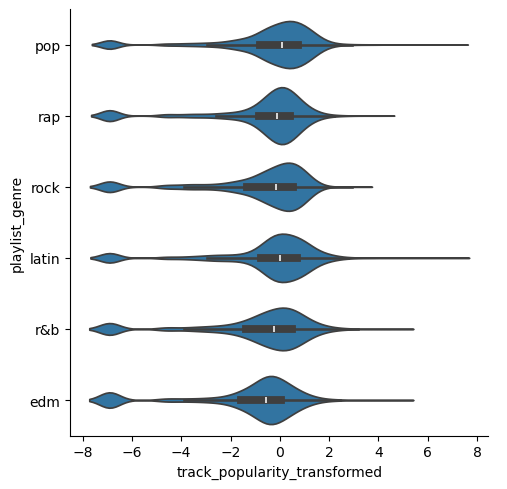

In [32]:
sns.catplot(data=df, x='track_popularity_transformed', y='playlist_genre', kind='violin')
plt.show()

This violin plot shows the relationship between the two variables: `track_popularity_transformed` and `playlist_genre`. All of the means seem to be below 0; however, most of their concentrations tend to be at or above 0. They all seem to have the outliers at the far left, but the Rock genre seems to have most of its values concentrated around the mean with its whiskers cut short. This means that Rock songs tend to have a more consistent popularity rating. Similarly to the other charts, I decided to use a violin plot to emphasize a genre's signficance, this case being the Rock genre. 

#### Continuous-to-continuous: ####

In [33]:
df_corr = df[['danceability', 'energy', 'loudness', 'valence', 'tempo', 'track_popularity_transformed']].corr()
df_corr

,danceability,energy,loudness,valence,tempo,track_popularity_transformed
danceability,1.000000,-0.086073,0.025335,0.330523,-0.184084,0.055520
energy,-0.086073,1.000000,0.676625,0.151103,0.149951,-0.108158
loudness,0.025335,0.676625,1.000000,0.053384,0.093767,0.027882
valence,0.330523,0.151103,0.053384,1.000000,-0.025732,0.013493
tempo,-0.184084,0.149951,0.093767,-0.025732,1.000000,-0.006647
track_popularity_transformed,0.055520,-0.108158,0.027882,0.013493,-0.006647,1.000000


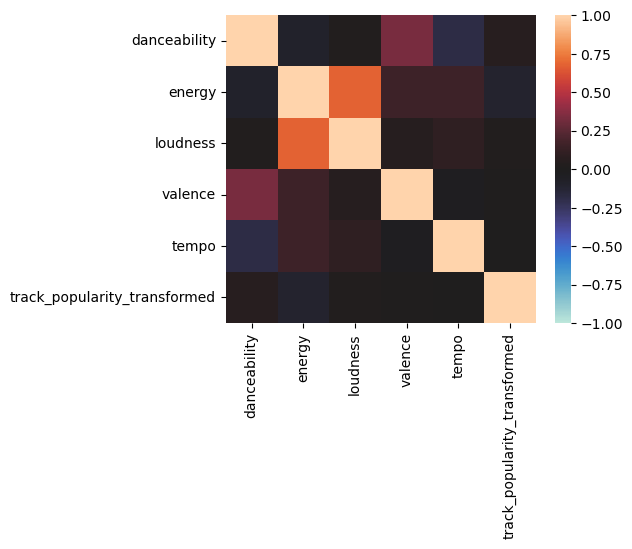

In [34]:
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(df_corr, vmin=-1, vmax=1, center=0, ax=ax)
plt.show()

Here I decided to calculate the correlation coefficients and create a correlation plot to show the correlations between all of the continuous variables I chose. It is clear that the highest correlation between two variables are `loudness` and `energy` with `valence` and `danceability` coming in second. Below are those relationships plotted. I decided to use a correlation plot to make it easier to see which variables have clear relationships with each other. 

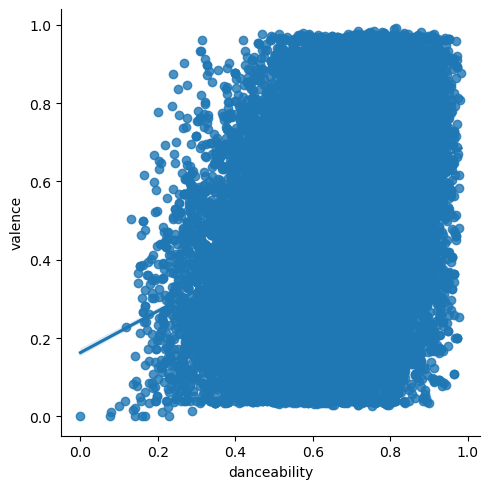

In [35]:
sns.lmplot(data=df, x="danceability", y="valence")
plt.show()

This scatter plot with a regression line shows the relationship between the variables: `danceability` and `valence`. While there seems to be a big bundle of points on the chart, we are able to see the positive correlation between the two variables with the regression line and with the help of the correlation plot. This suggests that the more danceable a song is, the more positive sounding it is and vice versa. I used a scatter plot with a regression line to help show the correlation.

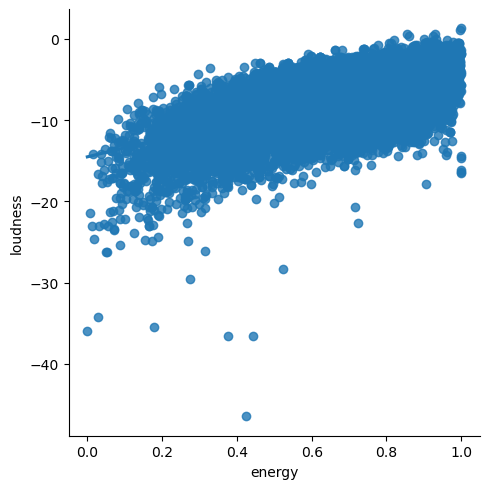

In [36]:
sns.lmplot(data=df, x="energy", y="loudness")
plt.show()

This scatter plot with a regression line shows the relationship between the variables: `energy` and `loudness`. It is clear that there is a significant positive correlation between the two variables. This suggests that the higher energy a song has, the louder it is.

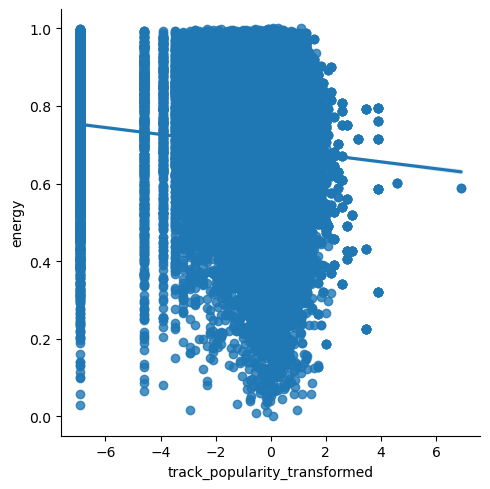

In [37]:
sns.lmplot(data=df, x="track_popularity_transformed", y="energy")
plt.show()

This scatter plot with a regression line shows the relationship between the variables: `track_popularity_transformed` and `energy`. While there is a slight negative correlation between the two variables, because the popularity variable is standardized, the correlation does not necessarily mean anything with this relationship. I decided to use a scatter plot with a regression line to help show that even though there might be a correlation, when you consider the context, the correlation might not mean what you think. 

**In this section, I explored the relationships between the variables I chose. I found that Rap and Latin songs are the two most danceable genres with Rock being the least danceable genre. I found two suggestions about the EDM genre that were not all that surprising. EDM having the highest energy level and highest tempo makes sense when you consider the context. I did find that the Rock genre had more consistent popularity ratings out of the other five genres which was interesting. I also found that the more positive sounding a song was, the more danceable it was and the more energy a song had, the louder it was.**

## 8. Relationships Grouped by Categorical Variables

#### Continuous-to-continuous: ####

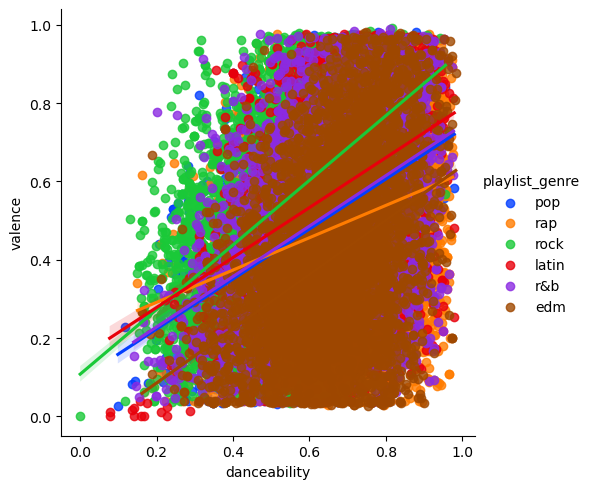

In [38]:
sns.lmplot(data=df, x="danceability", y="valence", hue="playlist_genre", palette='bright')
plt.show()

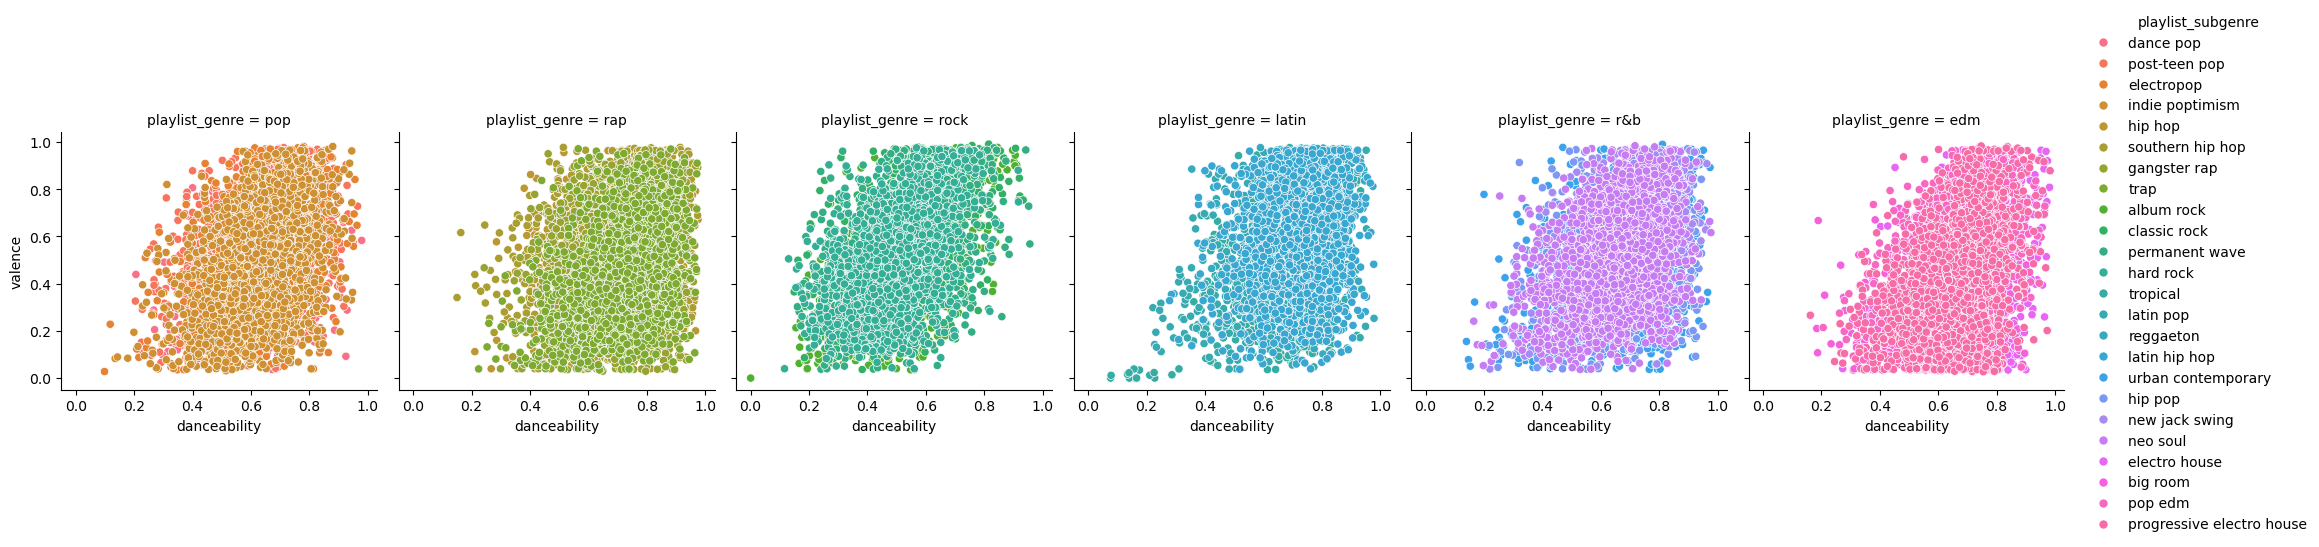

In [39]:
sns.relplot(data=df, x='danceability', y='valence', hue='playlist_subgenre', col='playlist_genre', height=3.5 )
plt.show()

Here we have two scatter plots that show the relationship between the two variables: `danceability` and `valence`. The first scatter plot is grouped by the variable `playlist_genre` and has regression lines for each genre. The second scatter plot is a faceted scatter plot that is grouped by the `playlist_genre` variable and highlights their respective subgenres with the `playlist_subgenre` variable. I decided to use both of these scatter plots to help show the relationship between the two variables across each genre. We can see that although they all have positive correlations, their respective data points are concentrated in different areas. For example, Rock seems to not be as danceable but has more positive sounding songs than the other genres, where as Rap seems to have more danceable songs but does not have more positive sounding songs. R&B and Pop seem to have almost identical correlations as each other which suggests that an R&B song should be just as danceable and positive sounding as a Pop song and vice versa. 

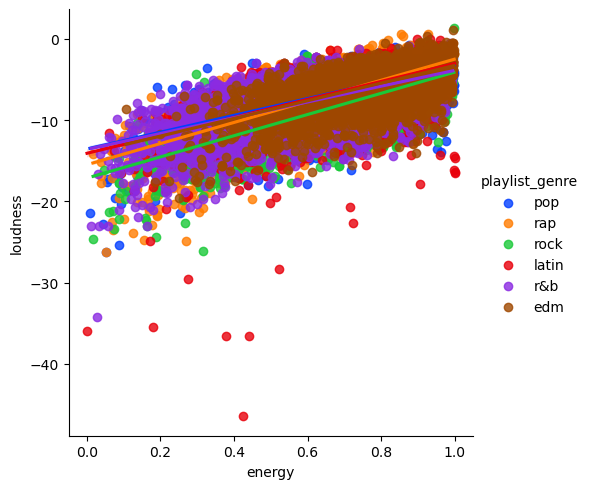

In [40]:
sns.lmplot(data=df, x="energy", y="loudness", hue="playlist_genre", palette='bright')
plt.show()

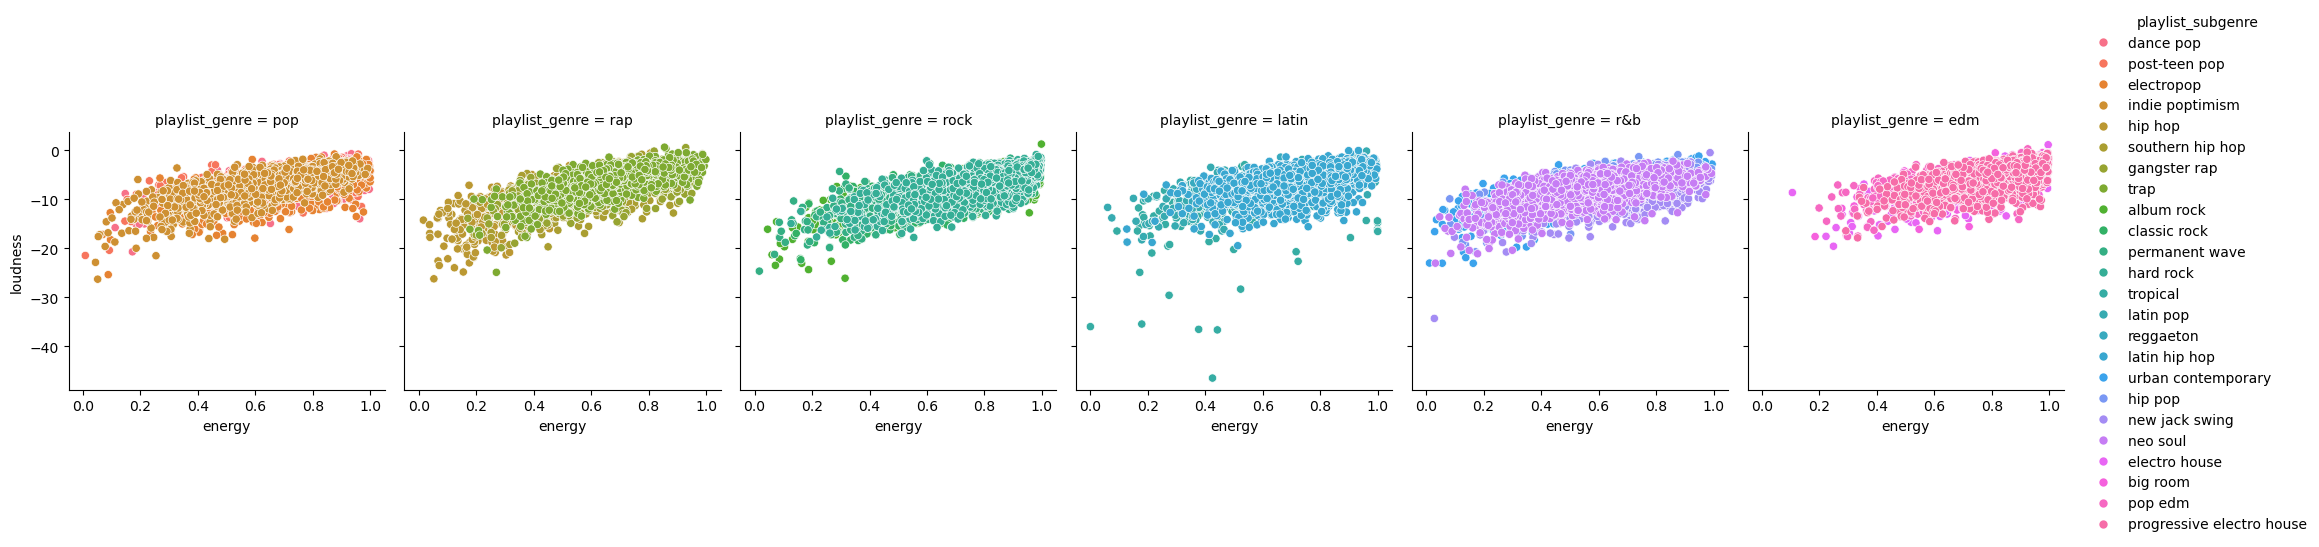

In [55]:
sns.relplot(data=df, x='energy', y='loudness', hue='playlist_subgenre', col='playlist_genre', height=3.5)
plt.show()

Here we have two scatter plots that show the relationship between the two variables: `energy` and `loudness`. The first scatter plot is grouped by the variable `playlist_genre` and has regression lines for each genre. The second scatter plot is a faceted scatter plot that is grouped by the `playlist_genre` variable and highlights their respective subgenres with the `playlist_subgenre` variable. I decided to use both of these scatter plots to help show the relationship between the two variables across each genre. Most of the genres tend to be very similar; however, Latin and EDM seem to be slightly different. The Latin genre seems to have significantly more outliers than the other genres meaning that they have more lower energy songs that are quiter. The EDM genre seems to be more concentrated with less lower energy and quieter songs.

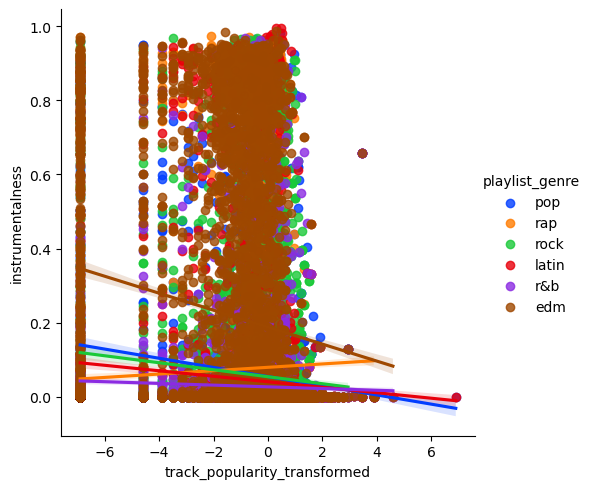

In [86]:
sns.lmplot(data=df, x="track_popularity_transformed", y="instrumentalness", hue="playlist_genre", palette='bright')
plt.show()

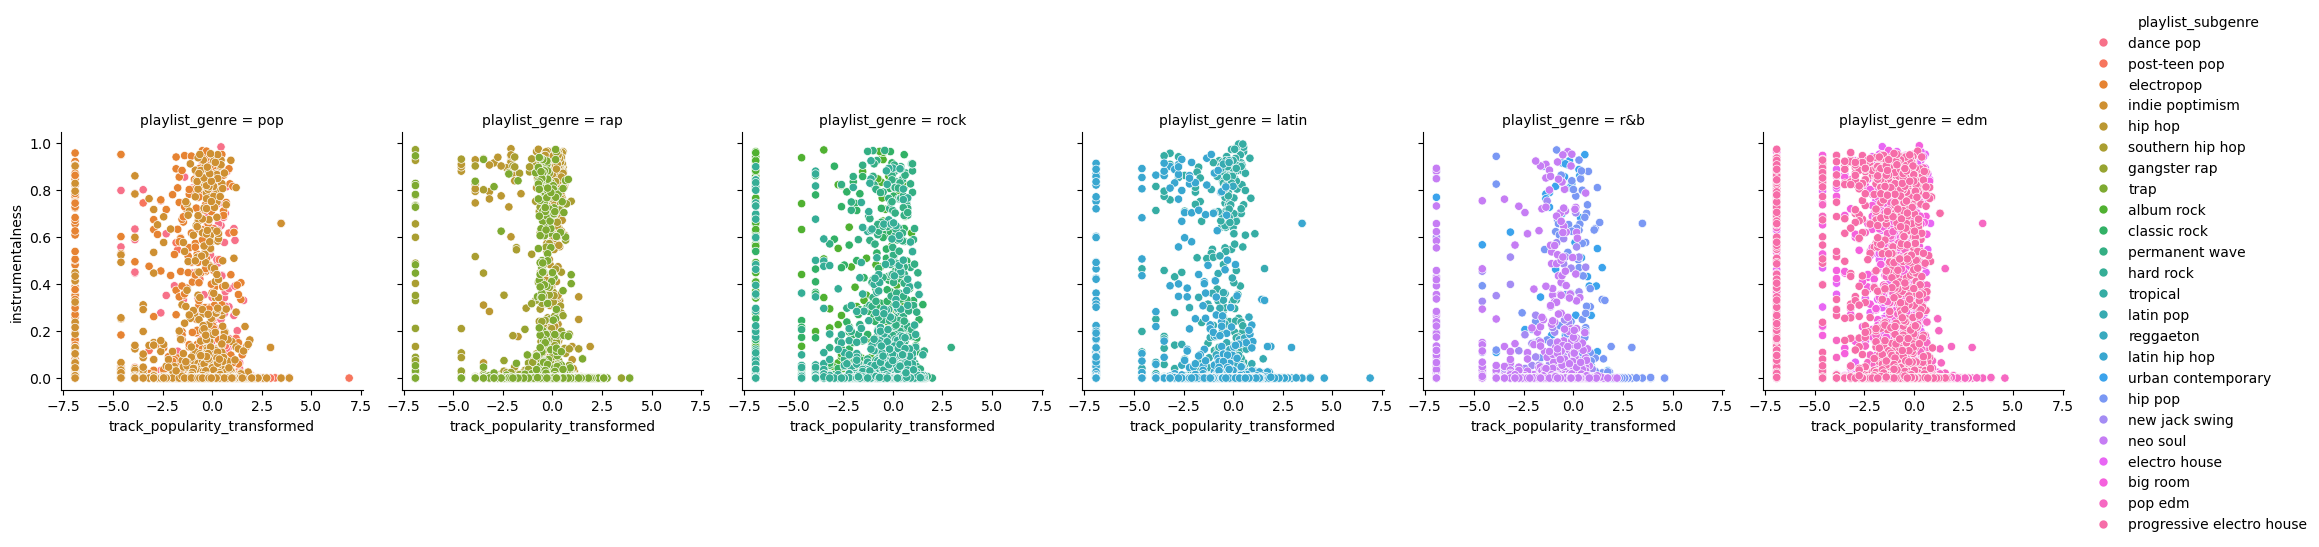

In [87]:
sns.relplot(data=df, x='track_popularity_transformed', y='instrumentalness', hue='playlist_subgenre', col='playlist_genre', height=3.5)
plt.show()

Here we have two scatter plots that show the relationship between the two variables: `track_popularity_transformed` and `instrumentalness`. The first scatter plot is grouped by the variable `playlist_genre` and has regression lines for each genre. The second scatter plot is a faceted scatter plot that is grouped by the `playlist_genre` variable and highlights their respective subgenres with the `playlist_subgenre` variable. I decided to use both of these scatter plots to help show the relationship between the two variables across each genre. Although we did see before that most of the songs tended to have more vocal content than not, here we see what looks like a more even distribution of songs across the `instrumentalness` variable. We see that the Rap genre has a more consistent popularity rating compared to the other genres, specifically the EDM genre. EDM seems to have much more variety in popularity rating then the other genres. The Rock genre seems to have a wider spread of popularity ratings, but has a bundle of lower instrumentalness values which means that the songs still have more vocal content. 

#### Categorical-to-continuous: ####

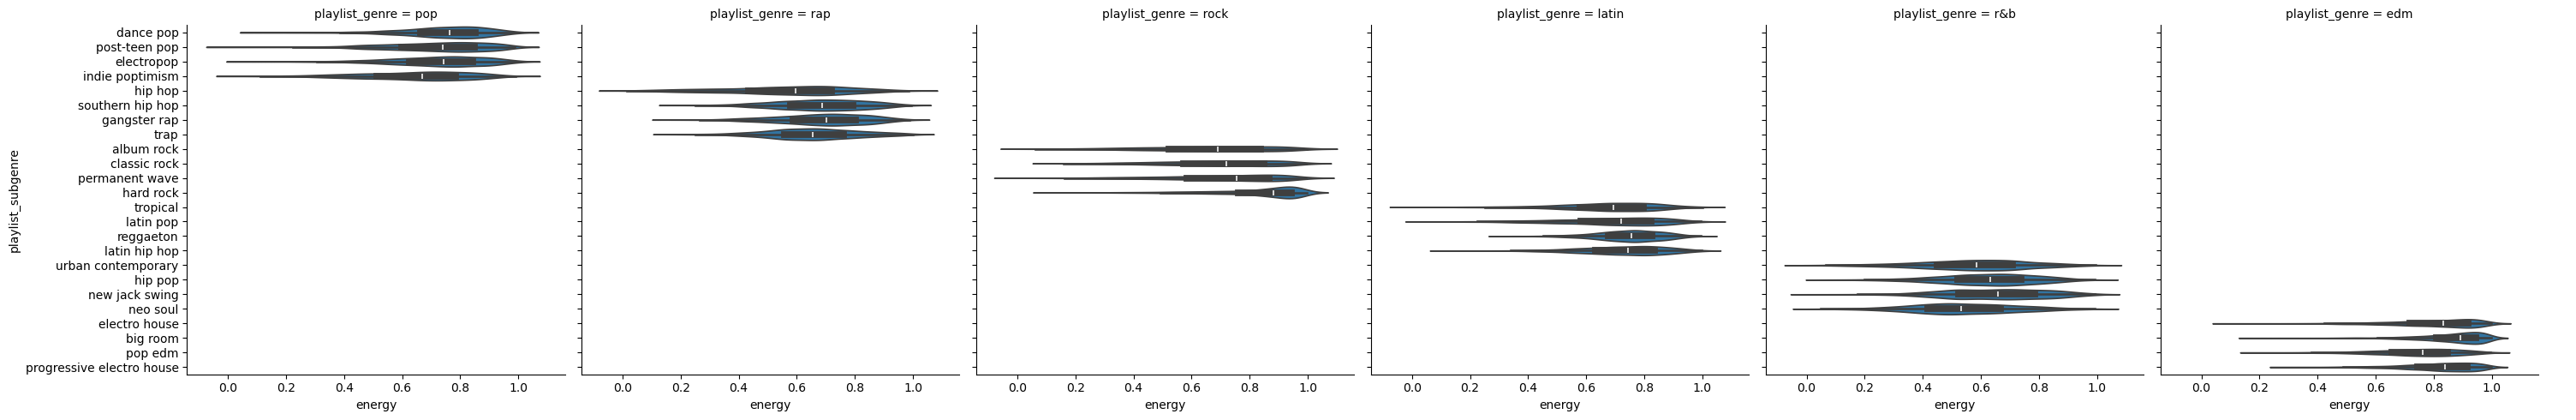

In [76]:
sns.catplot(data=df, x='energy', y='playlist_subgenre', col='playlist_genre', kind='violin')
plt.show()

This faceted violin chart shows the relationship between the two variables: `energy` and `playlist_subgenre`. The chart is grouped by the variable `playlist_genre` meaning that every subplot is a genre. I decided to use a faceted violin chart because it helps show differences between the subgenres within each genre. Within the genres Rock, R&B, and EDM, there seems to be a clear subgenre that tends to be either higher energy or lower energy than the other subgenres. For example, Hard Rock in the genre Rock, seems to have higher overall energy values. On the other hand, in the R&B genre, the subgenre Neo Soul seems to have lower overall energy values than the other subgenres. Similarly, in EDM, the Pop EDM subgenre seems to have lower overall energy values than the other subgenres. 

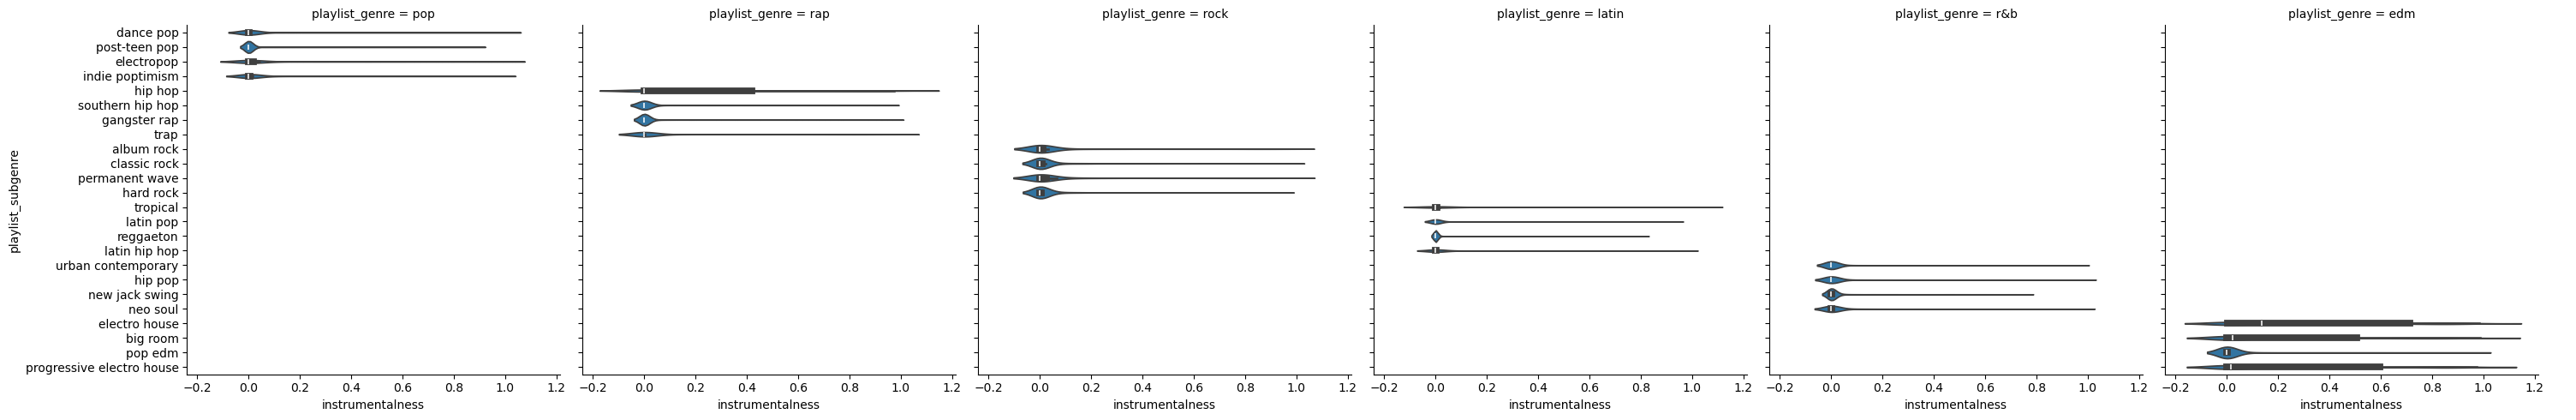

In [79]:
sns.catplot(data=df, x='instrumentalness', y='playlist_subgenre', col='playlist_genre', kind='violin')
plt.show()

This faceted violin chart shows the relationship between the two variables: `instrumentalness` and `playlist_subgenre`. The chart is grouped by the variable `playlist_genre` meaning that every subplot is a genre. I decided to use a faceted violin chart because it helps show differences between the subgenres within each genre. While most of the subgenres seem to have a tight range of values, there are some subgenres that have significantly wider ranges. For example, the subgenre Hip Hop in the Rap genre seems to have its middle 50% of values in between the 0.0-0.4 range. Similarly, in the EDM genre, there are three subgenres that have much wider ranges for their values in the middle 50%. This means that these subgenres tend to have a variety of songs that are higher and lower in vocal content compared to the other subgenres that consistently have high vocal content. 

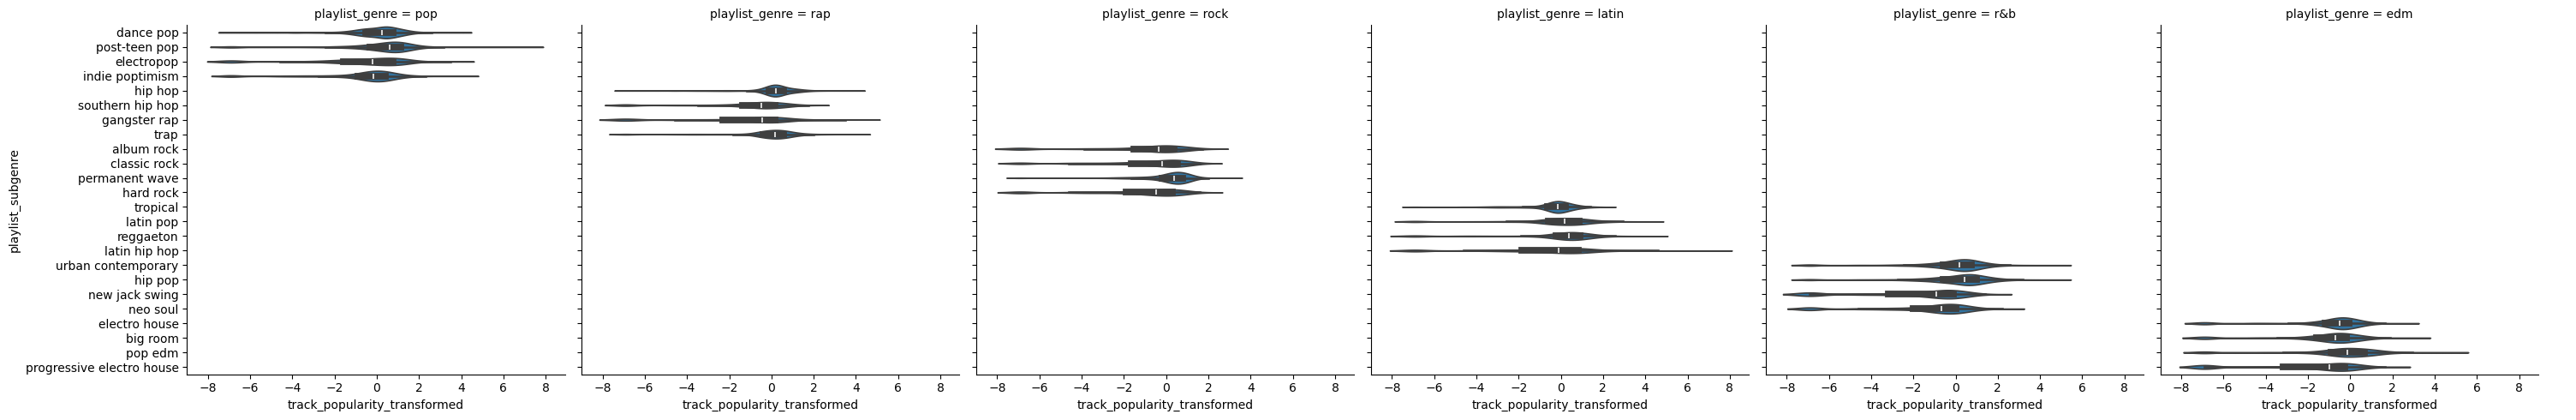

In [80]:
sns.catplot(data=df, x='track_popularity_transformed', y='playlist_subgenre', col='playlist_genre', kind='violin')
plt.show()

This faceted violin chart shows the relationship between the two variables: `track_popularity_transformed` and `playlist_subgenre`. The chart is grouped by the variable `playlist_genre` meaning that every subplot is a genre. I decided to use a faceted violin chart because it helps show differences between the subgenres within each genre. Based on the previous section, we found that Rock had the more consistent popularity ratings than any other genre; however, looking at these violin plots, we can see that the subgenres within the Latin genre, are the most consistent with each other near 0. This means that there are not common differences when it comes to popularity rating. On the other hand, even though we know that Rock has more consistent popularity ratings, we can see the subgenre, Permanent Wave, sits right on 0 and has its majority values on 0 meaning that the Permanent Wave subgenre has significantly more consistent popularity ratings than the other Rock subgenres. This is interesting because Permanent Wave has the second lowest amount of songs within the Rock genre which further proves that its popularity ratings do not vary as much as other subgenres. 

**In this section, I explored the relationships of variables grouped by categorical variables using some of the variables that I chose. I first grouped by the `playlist_genre` variable and found that the rock songs tend to be more positive sounding but not as danceable and rap songs were the opposite. I then grouped by the variable `playlist_subgenre` and found nuances within the genres. For example, even though I found in the previous section that Rock songs had more consitent popularity ratings, when I explored the subgenres, I found that the one subgenre in Rock had most of the consistent popularity ratings. I also found that the Latin subgenres had were consistent with each other in popularity ratings.**

## 9. Findings and Discussion

#### Which of the inputs do you think influence that outcome variable (song popularity), based on your exploratory visualizations? ####

I was not able to find any specific continuous variables that were able to influence the outcome variable; however, I did notice that the genres and subgenres had influence. As stated previously, I found that the Rock and Latin genres had consistent populartiy ratings meaning they had significant influence. The other genres had a wide variety of consitency meaning their popularity ratings varied significantly. 

#### Which exploratory visualizations helped you identify potential relationships between song popularity and other variables? ####

There were three visualizations that helped me signficantly in this exploratory analysis. These were the Faceted Violin Plots, Scatter Plots with Regression Lines, and the Correlation Plot. The Violin Plot helped me see the nuances of the subgenres within each genre. The Scatter Plots with Regression Lines helped me see if there any positive or negative correlations between variables. The Correlation Plot helped me decide which continuous-to-continuous relationships to look further into.